,price_close,price_high,price_low,team,event,opp,price_close_prev,price_high_prev,price_low_prev,oai_negative_mean,...,oai_neutral_std_opp,oai_positive_mean_opp,oai_positive_std_opp,vader_neg_mean_opp,vader_neg_std_opp,vader_neu_mean_opp,vader_neu_std_opp,vader_pos_mean_opp,vader_pos_std_opp,team_opp
end_period_ts,,,,,,,,,,,,,,,,,,,,,
2025-11-02 23:00:00,0.48,0.48,0.48,NE,25NOV09NETB,TB,0.48,0.48,0.45,2.62,...,4.6,1.88,3.96,1.02,1.07,7.31,1.61,2.11,0.96,TB
2025-11-03 00:00:00,0.46,0.46,0.46,NE,25NOV09NETB,TB,0.48,0.48,0.48,2.22,...,5.3,2.80,4.86,1.62,1.26,6.22,0.90,1.54,0.84,TB
2025-11-03 01:00:00,0.45,0.46,0.44,NE,25NOV09NETB,TB,0.46,0.46,0.46,1.21,...,0.0,0.00,0.00,2.03,0.00,7.61,0.00,0.68,0.00,TB
2025-11-03 02:00:00,0.45,0.45,0.45,NE,25NOV09NETB,TB,0.45,0.46,0.44,1.97,...,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,TB
2025-11-03 03:00:00,0.44,0.45,0.44,NE,25NOV09NETB,TB,0.45,0.45,0.45,3.03,...,0.0,0.00,0.00,0.00,0.00,7.86,0.00,0.85,0.00,TB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-23 11:00:00,0.78,0.78,0.77,NE,25NOV23NECIN,CIN,0.78,0.78,0.76,0.00,...,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,CIN
2025-11-23 12:00:00,0.78,0.78,0.76,NE,25NOV23NECIN,CIN,0.78,0.78,0.77,0.00,...,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,CIN
2025-11-23 13:00:00,0.78,0.78,0.76,NE,25NOV23NECIN,CIN,0.78,0.78,0.76,0.00,...,0.0,0.00,0.00,0.00,0.00,8.59,0.38,0.68,0.38,CIN


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-1619.624, Time=1.51 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-1527.683, Time=0.61 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-1525.705, Time=0.37 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-1525.709, Time=0.66 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-1621.611, Time=1.44 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-1623.050, Time=0.93 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=-1622.164, Time=2.23 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-1523.671, Time=0.15 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=-1620.092, Time=1.62 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=-1622.942, Time=2.28 sec

Best model:  ARIMA(0,0,2)(0,0,0)[0]          
Total fit time: 11.833 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  386
Model:               SARIMAX(0, 0, 2)   Log Likelih

c:\Users\cowil\OneDrive\Python\Capstone\Kalshi_stat_arb\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\cowil\OneDrive\Python\Capstone\Kalshi_stat_arb\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


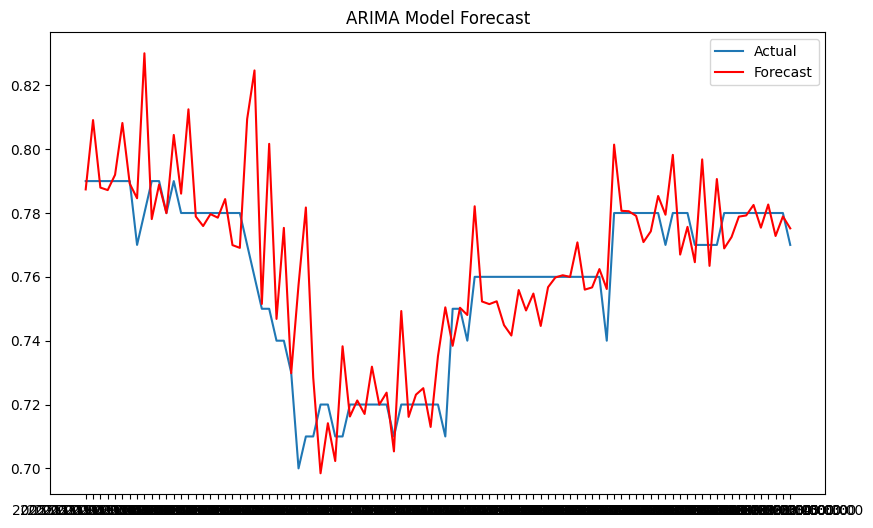

In [1]:
from pmdarima import auto_arima
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
from utils.constants import KALSHI_FEATURE_COLS

df = pd.read_csv('data/Kalshi_reddit_sentiment_combined.csv',index_col=0)
team = 'NE'
train_df = df[df['team']==team].copy()
display(train_df)

train_df.sort_index(inplace=True)
train_df.dropna(inplace=True)  

# Define the target variable and exogenous variable
y = train_df['price_close']
X = train_df[KALSHI_FEATURE_COLS] #,'price.close_prev','price.high_prev','price.low_prev'

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Fit the ARIMA model with exogenous variable
model = auto_arima(y_train, X=X_train, seasonal=False, trace=True, error_action='ignore', suppress_warnings=True)

# Summary of the model
print(model.summary())

# Make predictions
forecast = model.predict(n_periods=len(X_test), X=X_test)

# Compare predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, forecast, label='Forecast', color='red')
plt.legend()
plt.title('ARIMA Model Forecast')
plt.show()